In [8]:
import sb_bond_functions as ba
import MDAnalysis as mda
import pandas as pd
import numpy as np

In [2]:
reference_struc = 'centered_active.gro' 
trajectory = ['test.xtc'] 
ma_window = 25

In [3]:
all_pairs, current_pairs, combined_coords, n_mainchain_residues = ba.compute_com_contacts(trajectory, reference_struc, batch_size=100, stride=1, 
                         contact_threshold=8.0, variance_percentile=75, n_jobs=1)

/home/romiromi/work/.venv/lib/python3.12/site-packages/MDAnalysis/coordinates/XDR.py:253: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
test.xtc: 100%|██████████| 251/251 [00:02<00:00, 90.77it/s]


Total contact pairs: 2178828


Stage 1: Contact Filter:   0%|          | 0/21789 [00:00<?, ?it/s]/home/romiromi/work/bond_analysis/bondflow/salt_bridge_analysis/sb_bond_functions.py:173: RuntimeWarning: All-NaN slice encountered
  min_distances = np.nanmin(batch_distances, axis=0)
Stage 1: Contact Filter: 100%|██████████| 21789/21789 [01:44<00:00, 207.73it/s]


Pairs after contact filter: 21,041


Stage 2: Variance Filter: 100%|██████████| 211/211 [00:01<00:00, 173.48it/s]

Pairs after variance filter: 5,261


In [6]:
def pairs_to_dataframe(pairs, n_mainchain_residues, protein_residues):
    """
    Convert index pairs to a pandas DataFrame with residue names, numbers, and chain types.
    """
    data = []
    
    for i, j in pairs:
        type_i = 'MC' if i < n_mainchain_residues else 'SC'
        type_j = 'MC' if j < n_mainchain_residues else 'SC'
        
        # Map to residue index within main chain block
        resid_i = protein_residues[i % n_mainchain_residues]
        resid_j = protein_residues[j % n_mainchain_residues]
        
        res_i_str = f"{resid_i.resname}{resid_i.resid}"
        res_j_str = f"{resid_j.resname}{resid_j.resid}"
        pair_name = f"{res_i_str}({type_i})_{res_j_str}({type_j})"
        
        data.append([res_i_str, type_i, res_j_str, type_j, pair_name, i, j])
    
    df = pd.DataFrame(data, columns=['residue_i', 'type_i', 'residue_j', 'type_j', 'pair_name', 'idx_i', 'idx_j'])
    return df
def compute_residue_pair_distances(coords, pairs, n_mainchain_residues, protein_residues):
    """
    Compute distances between residue pairs across trajectory frames, including bond type (MC-MC, MC-SC, etc.).
    """
    n_frames = coords.shape[0]

    # Build pair metadata table
    df_pairs = pairs_to_dataframe(pairs, n_mainchain_residues, protein_residues)
    
    # Define bond type (MC-MC, MC-SC, etc.)
    df_pairs["bond_type"] = df_pairs["type_i"] + "-" + df_pairs["type_j"]
    
    # Compute distances for each frame
    all_distances = []
    for _, row in df_pairs.iterrows():
        idx_i, idx_j = int(row["idx_i"]), int(row["idx_j"])
        diff = coords[:, idx_i, :] - coords[:, idx_j, :]
        dist = np.linalg.norm(diff, axis=1)  # shape: (n_frames,)
        all_distances.append(dist)
    
    # Convert to DataFrame
    distance_df = pd.DataFrame(all_distances, columns=[f"frame_{i}" for i in range(n_frames)])
    
    # Merge with metadata
    df_full = pd.concat([df_pairs.reset_index(drop=True), distance_df], axis=1)
    
    # Add summary stats
    frame_cols = [f"frame_{i}" for i in range(n_frames)]
    df_full["mean_distance"] = df_full[frame_cols].mean(axis=1)
    df_full["std_distance"] = df_full[frame_cols].std(axis=1)

    return df_full


In [9]:
model = mda.Universe(reference_struc, trajectory)
protein_residues = model.select_atoms("protein").residues
df = compute_residue_pair_distances(combined_coords, current_pairs, n_mainchain_residues, protein_residues)
print(df.head())

  residue_i type_i residue_j type_j            pair_name  idx_i  idx_j  \
0      PHE1     MC    LEU361     MC  PHE1(MC)_LEU361(MC)      0    360   
1      PHE1     MC    ASP362     MC  PHE1(MC)_ASP362(MC)      0    361   
2      PHE1     MC    TYR588     MC  PHE1(MC)_TYR588(MC)      0    587   
3      PHE1     MC      PHE1     SC    PHE1(MC)_PHE1(SC)      0   1044   
4      PHE1     MC    ARG449     SC  PHE1(MC)_ARG449(SC)      0   1492   

  bond_type   frame_0    frame_1  ...  frame_243  frame_244  frame_245  \
0     MC-MC  8.628516   7.800342  ...   8.092579   7.545135   7.019318   
1     MC-MC  8.454235   7.345939  ...   7.083347   6.594049   6.426653   
2     MC-MC  9.494129  10.117542  ...   9.262227   9.193528   9.293634   
3     MC-SC  1.802906   2.255840  ...   1.569605   1.810123   1.759999   
4     MC-SC  6.411882   6.374126  ...   8.313202   7.601222   7.853355   

   frame_246  frame_247  frame_248  frame_249  frame_250  mean_distance  \
0   7.756611   7.138766   7.772880 

In [5]:
df_pairs = ba.pairs_to_dataframe(current_pairs, n_mainchain_residues, protein_residues)

In [9]:
import pandas as pd
df = df_pairs

# Define bond type (MC-MC, MC-SC, etc.)
df["bond_type"] = df["type_i"] + "-" + df["type_j"]

df = df[df["residue_i"] != df["residue_j"]].copy()

# Create a residue pair key that is **order-insensitive**
# so PHE1_LEU361 and LEU361_PHE1 are considered the same pair
df["residue_pair"] = df.apply(
    lambda x: "_".join(sorted([x["residue_i"], x["residue_j"]])), axis=1
)

# --- Create a reversed DataFrame to capture SC-MC equivalences ---
# This effectively adds reversed pairs so MC-SC and SC-MC can be seen together
reversed_df = df.copy()
reversed_df["residue_i"], reversed_df["residue_j"] = df["residue_j"], df["residue_i"]
reversed_df["type_i"], reversed_df["type_j"] = df["type_j"], df["type_i"]
reversed_df["bond_type"] = reversed_df["type_i"] + "-" + reversed_df["type_j"]
reversed_df["residue_pair"] = reversed_df.apply(
    lambda x: "_".join(sorted([x["residue_i"], x["residue_j"]])), axis=1
)

# Merge original and reversed
combined = pd.concat([df, reversed_df], ignore_index=True)

# --- Group and aggregate all bond types per residue pair ---
bond_summary = (
    combined.groupby("residue_pair")["bond_type"]
    .unique()
    .reset_index()
    .rename(columns={"bond_type": "bond_types"})
)

# --- Optional: add boolean columns for easy filtering ---
for bond_type in ["MC-MC", "MC-SC", "SC-MC", "SC-SC"]:
    bond_summary[bond_type] = bond_summary["bond_types"].apply(
        lambda x: bond_type in x
    )

print(bond_summary)


       residue_pair             bond_types  MC-MC  MC-SC  SC-MC  SC-SC
0     ALA103_GLY102                [MC-MC]   True  False  False  False
1     ALA103_GLY106         [MC-SC, SC-MC]  False   True   True  False
2     ALA103_TRP100                [MC-MC]   True  False  False  False
3     ALA107_ARG106                [MC-MC]   True  False  False  False
4     ALA107_GLU171                [MC-MC]   True  False  False  False
...             ...                    ...    ...    ...    ...    ...
3626  VAL383_VAL401                [MC-MC]   True  False  False  False
3627   VAL404_VAL75         [MC-SC, SC-MC]  False   True   True  False
3628  VAL434_VAL436  [MC-SC, SC-SC, SC-MC]  False   True   True   True
3629  VAL435_VAL445                [MC-MC]   True  False  False  False
3630  VAL444_VAL445                [MC-MC]   True  False  False  False

[3631 rows x 6 columns]


In [13]:
def remove_duplicate_pairs(current_pairs, protein_residues, n_mainchain_residues):
    """
    Keep the first encounter of each unique residue-residue pair (by name + number),
    regardless of mainchain/sidechain composition.
    Excludes self-pairs (e.g., VAL495–VAL495).
    """

    seen = set()
    unique_pairs = []

    for i, j in current_pairs:
        res_i = protein_residues[i % n_mainchain_residues]
        res_j = protein_residues[j % n_mainchain_residues]

        # Build residue identifiers (e.g., VAL495)
        res_i_name = f"{res_i.resname}{res_i.resid}"
        res_j_name = f"{res_j.resname}{res_j.resid}"

        # Skip self-pairs (same residue name and id)
        if res_i_name == res_j_name:
            continue

        # Canonical key ignores order (A_B == B_A)
        key = "_".join(sorted([res_i_name, res_j_name]))

        if key not in seen:
            unique_pairs.append((i, j))
            seen.add(key)

    return unique_pairs


# Example usage
unique_pairs = remove_duplicate_pairs(current_pairs, protein_residues, n_mainchain_residues)
print(f"Original pairs: {len(current_pairs)}")
print(f"Unique pairs:   {len(unique_pairs)}")


Original pairs: 5261
Unique pairs:   3631


In [14]:
filtered_pairs = ba.map_combined_to_original(unique_pairs, n_mainchain_residues)
print(f"Filtered pairs: {len(filtered_pairs)}")

Filtered pairs: 3631


In [15]:
binary_contact_map, distance_map, contact_map_names = ba.salt_bridge_contact_map_filtered(reference_struc, trajectory, filtered_pairs, distance_threshold=5.0)

In [17]:
print(binary_contact_map.shape)

(103, 251)


In [18]:
#print('Making contact maps, this will take a while...')
binary_contact_map, distance_map, contact_map_names = ba.salt_bridge_contact_map(reference_struc, trajectory)
#print('Contact map made') 

print(binary_contact_map.shape)

(11132, 251)


In [28]:
#Analyse the salt bridges that are formed or broken during simulation. Salt bridge residue pairs are sorted from the highest standard deviation to lowest. 
distance_df, sb_names, df_std_sorted = ba.create_sorted_distance_dataframe(contact_map_names, binary_contact_map, distance_map)
#Create new contact map with the distances with only the interesting salt bridges.
contact_map, contact_map_names2 = ba.create_contact_map_from_dataframe(distance_df)

In [33]:
#Make new contact map by using a moving average on the original binary contact map. Making the movement of contacts smoother.
ma_binary_contact_map = ba.moving_average_contact_map_maker(contact_map,2)

#distance_df2, sb_names_list2 = ba.create_sorted_distance_dataframe(contact_map_names, ma_binary_contact_map, distance_map)

#ma_contact_map, ma_contact_map_names = ba.create_contact_map_from_dataframe(distance_df2)

In [34]:
print(ma_binary_contact_map.shape)

(251, 104)


/var/data/python/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


<Axes: >

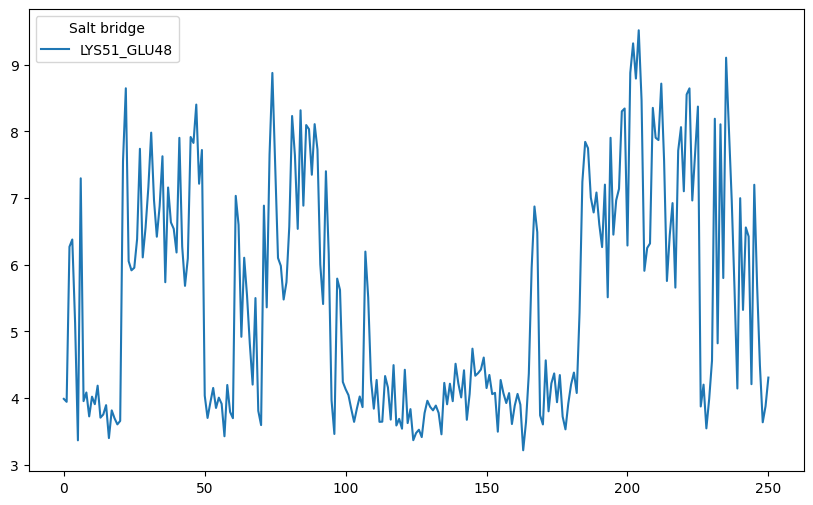

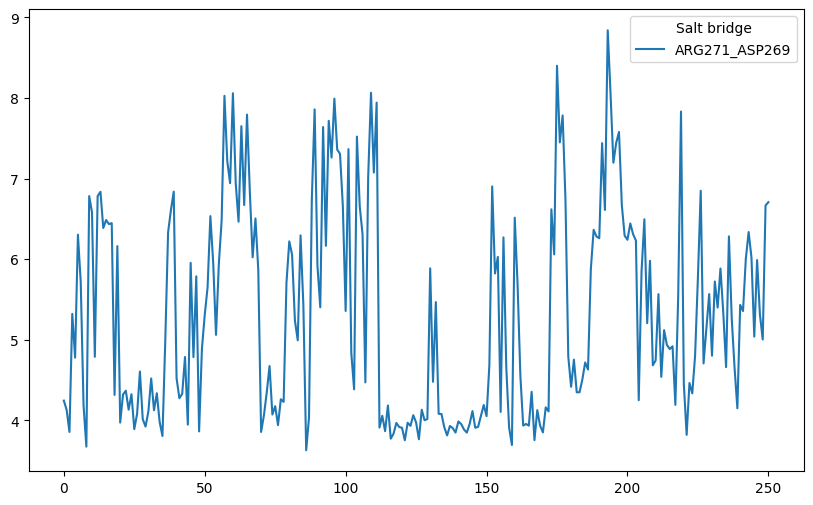

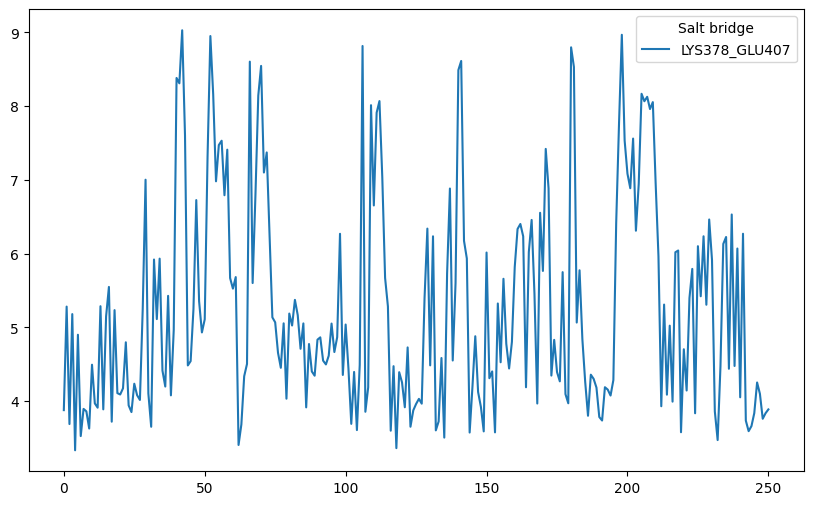

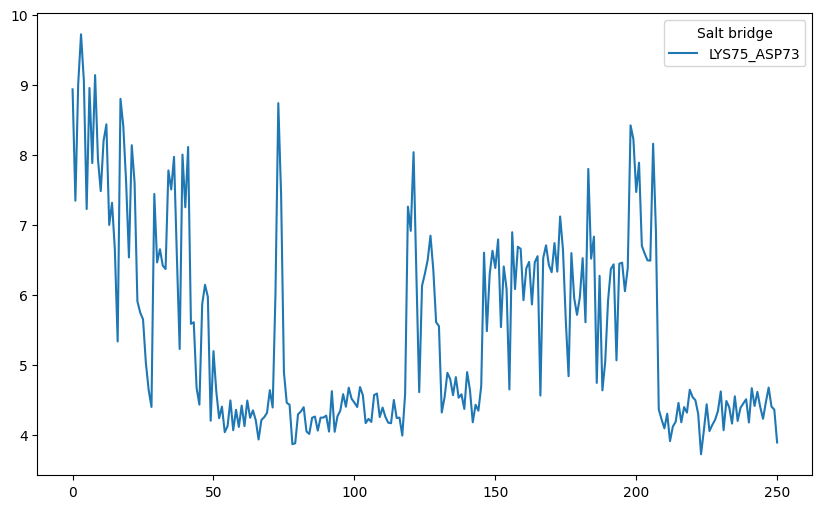

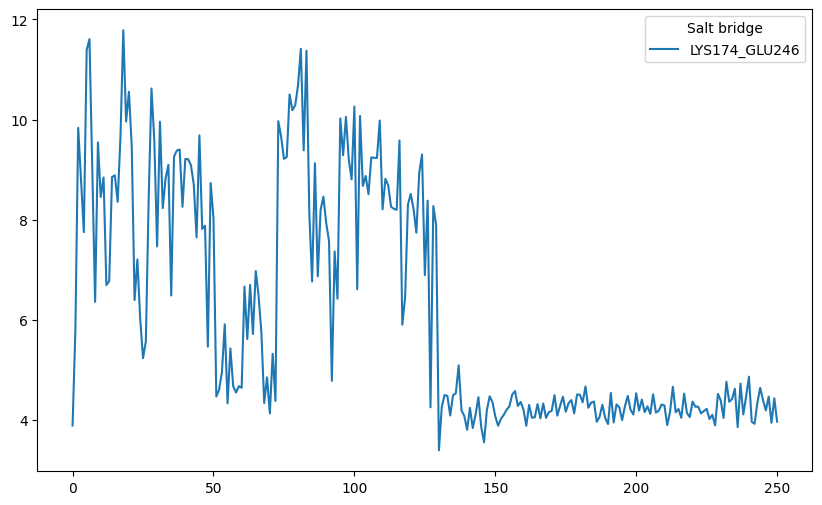

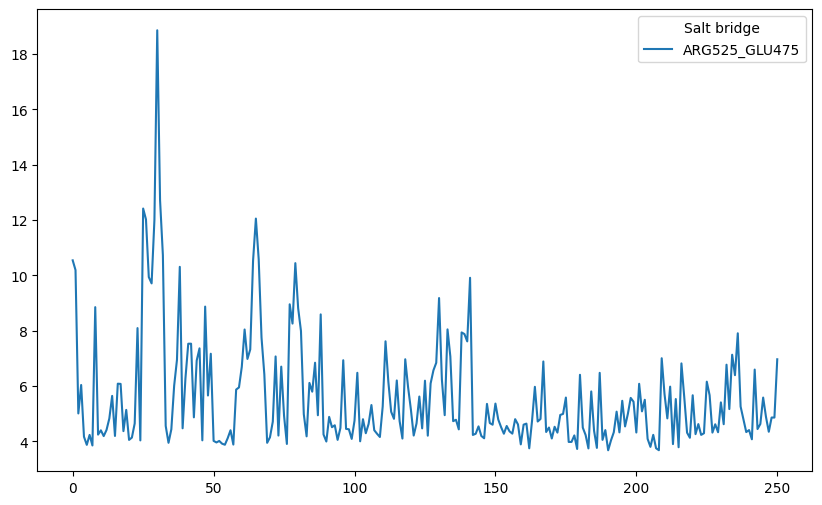

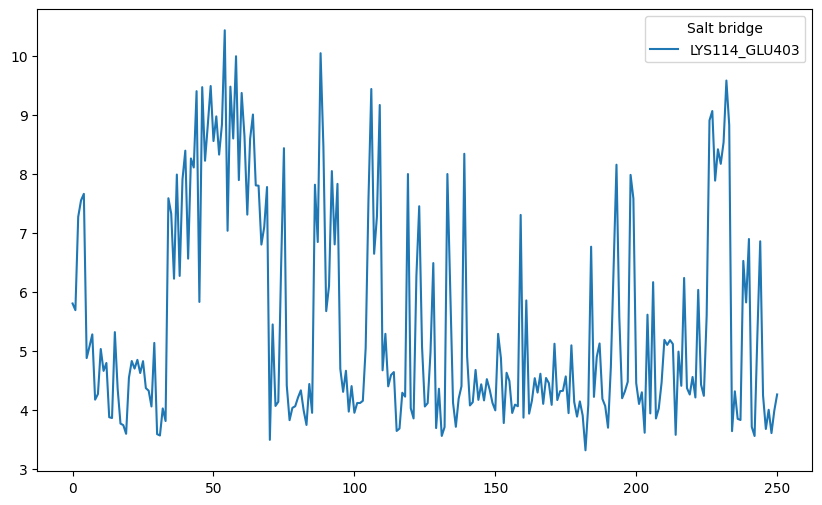

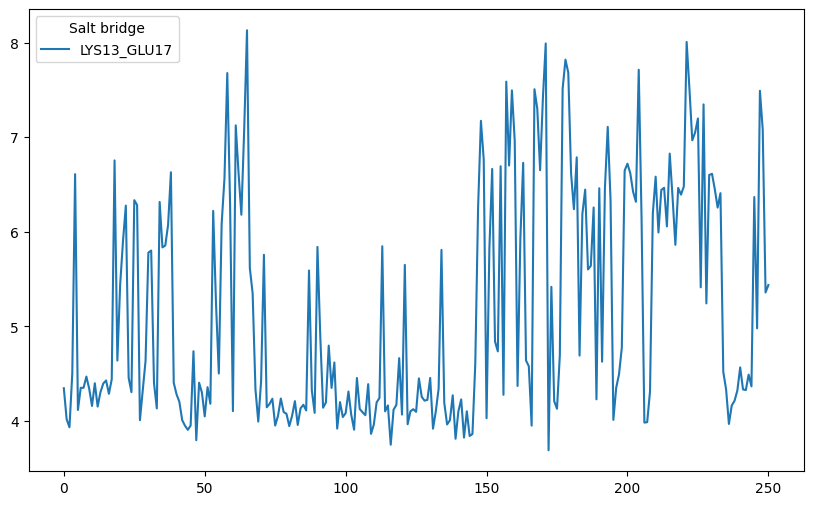

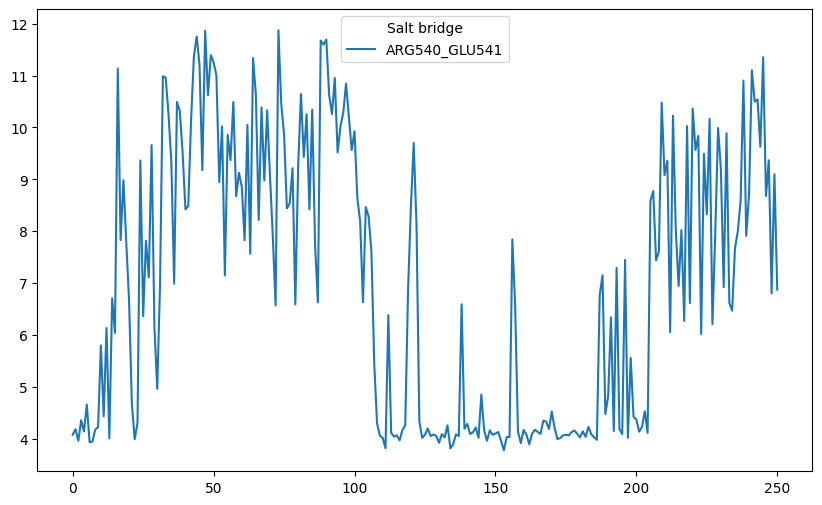

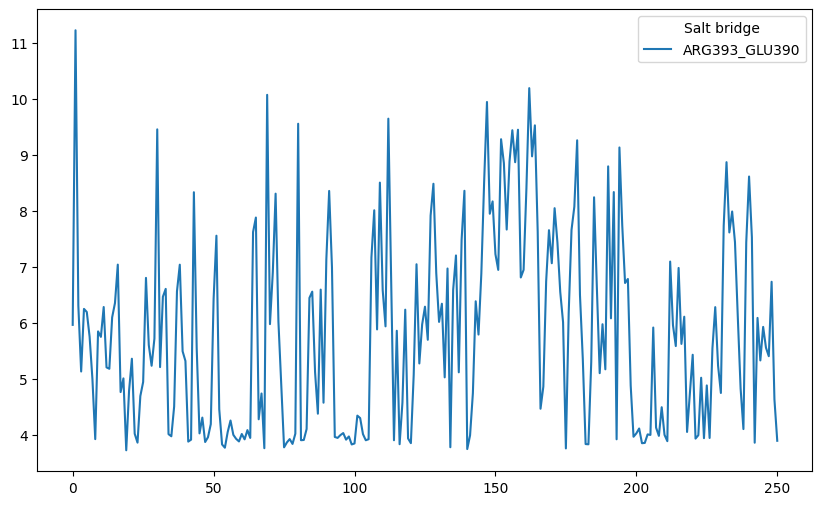

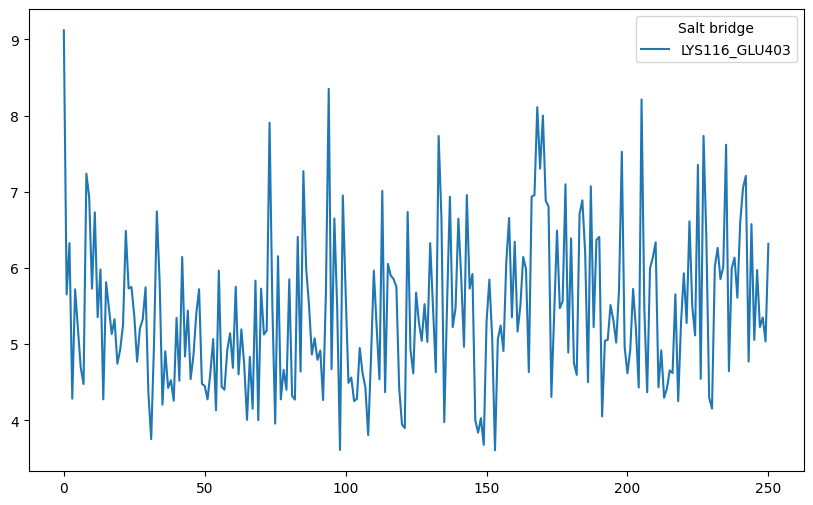

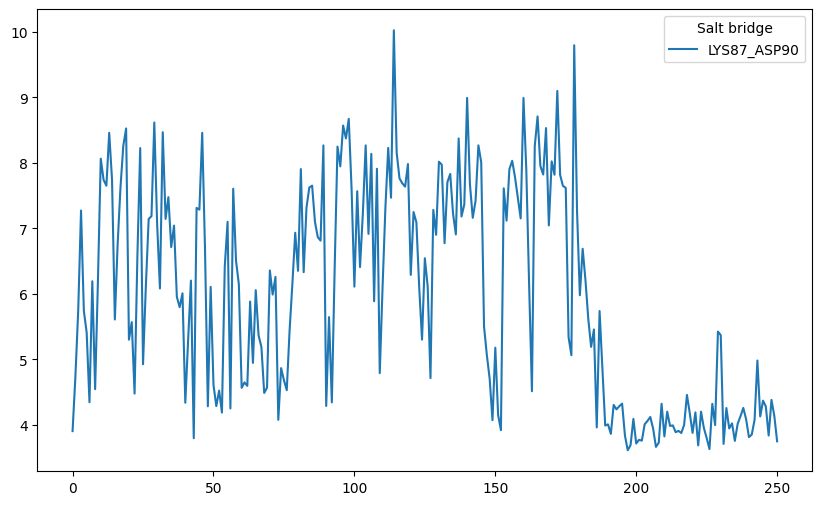

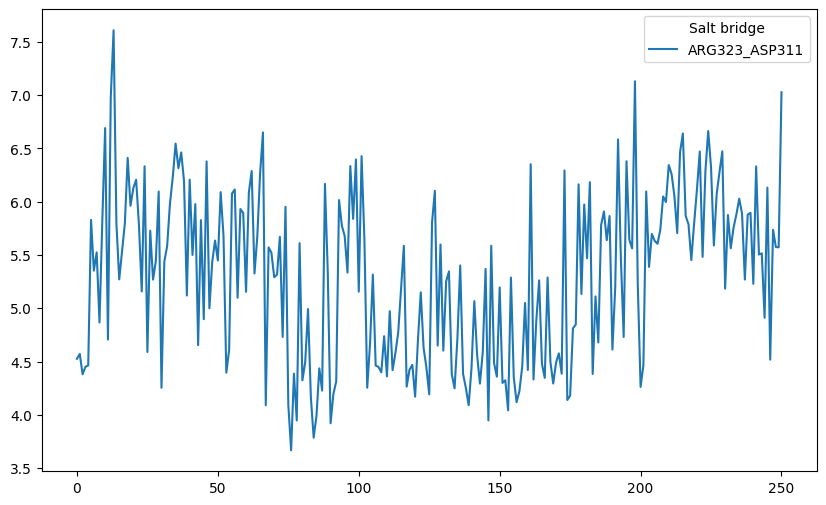

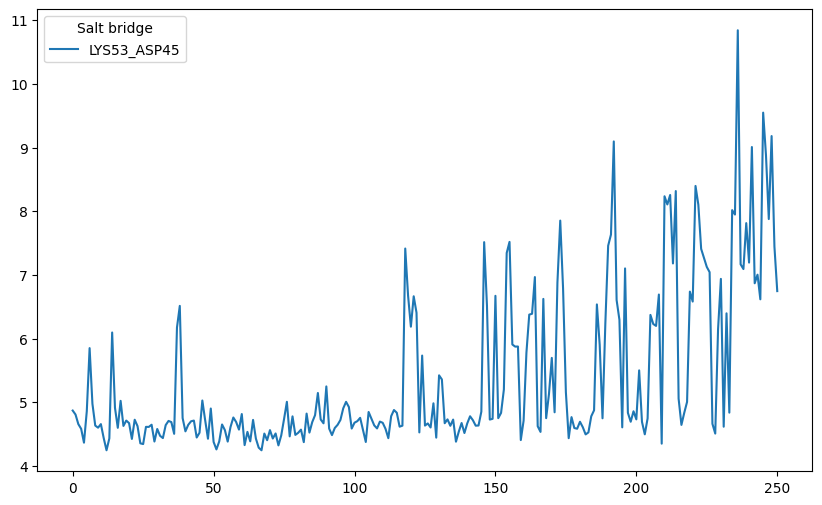

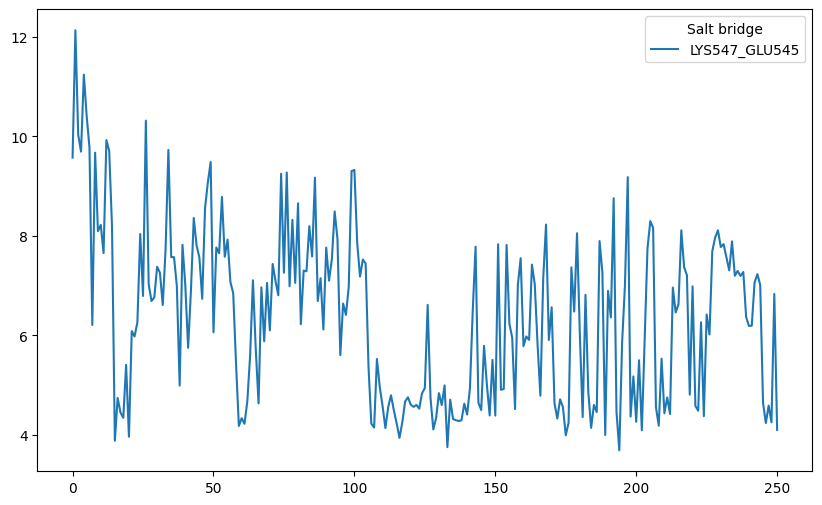

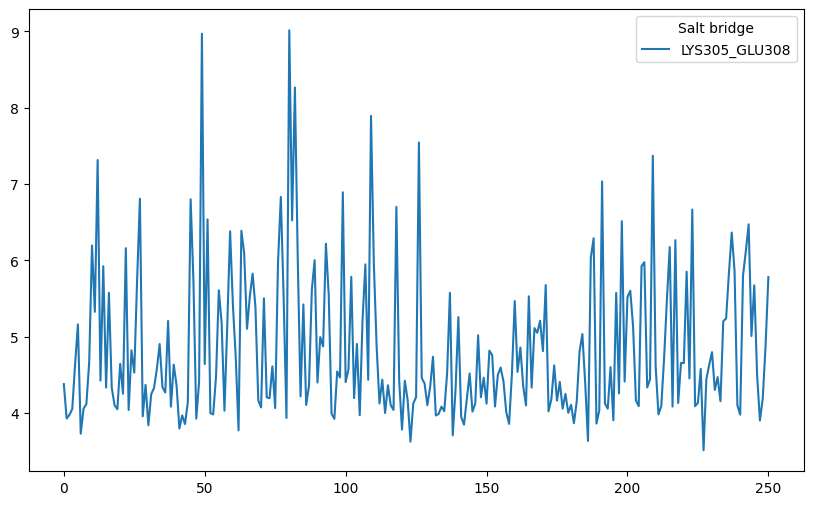

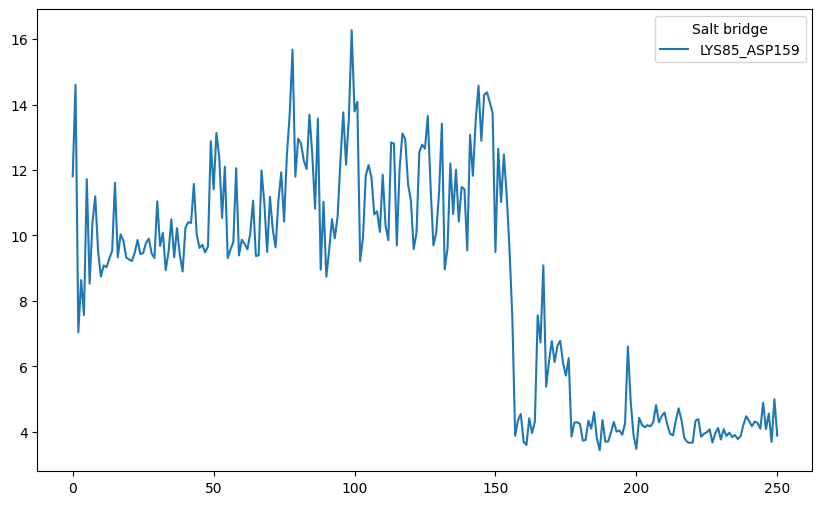

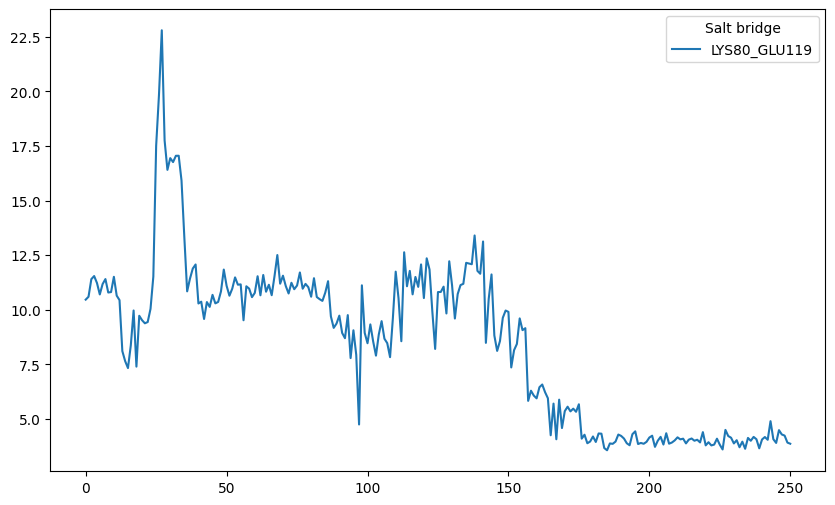

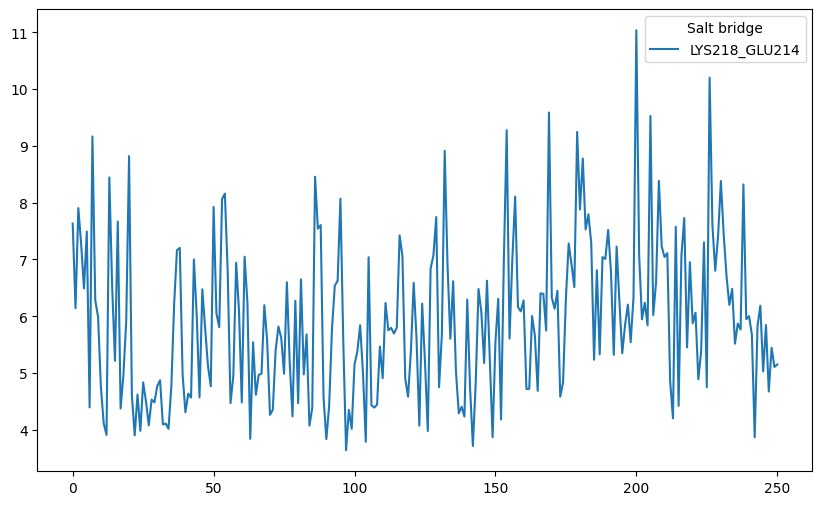

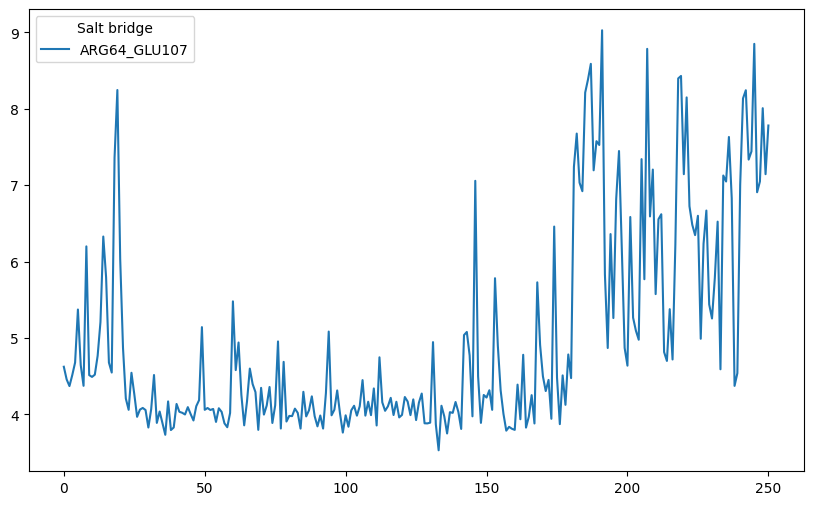

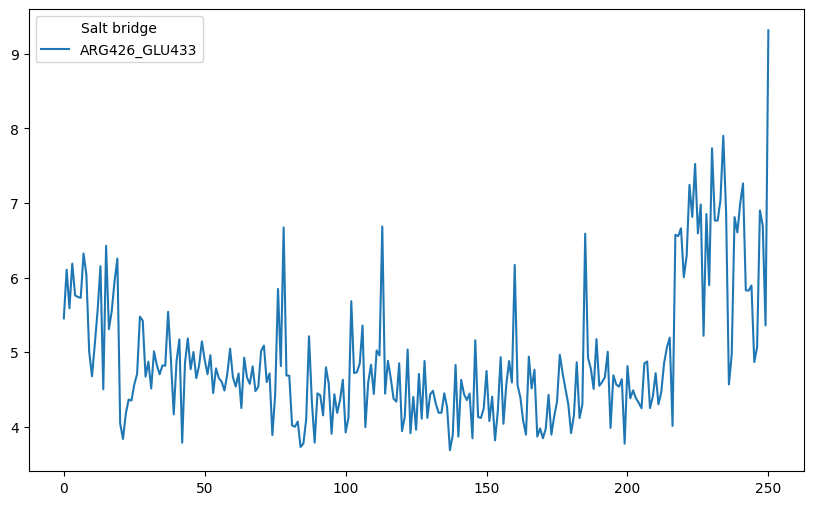

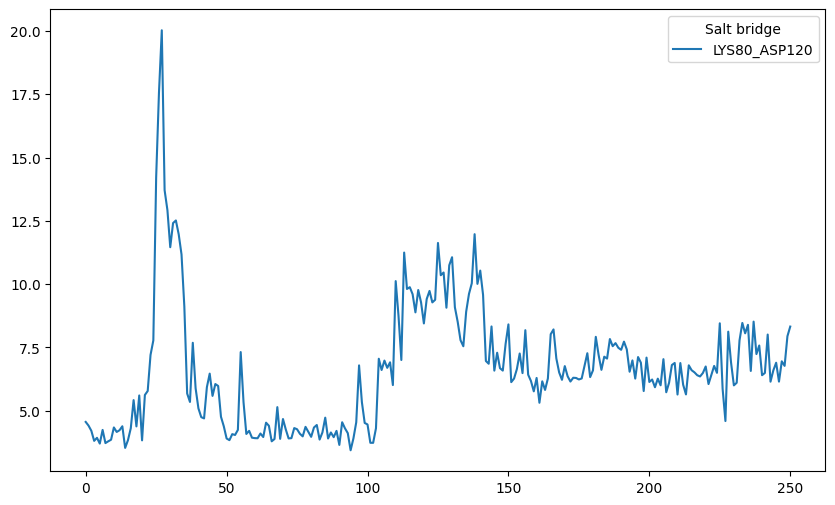

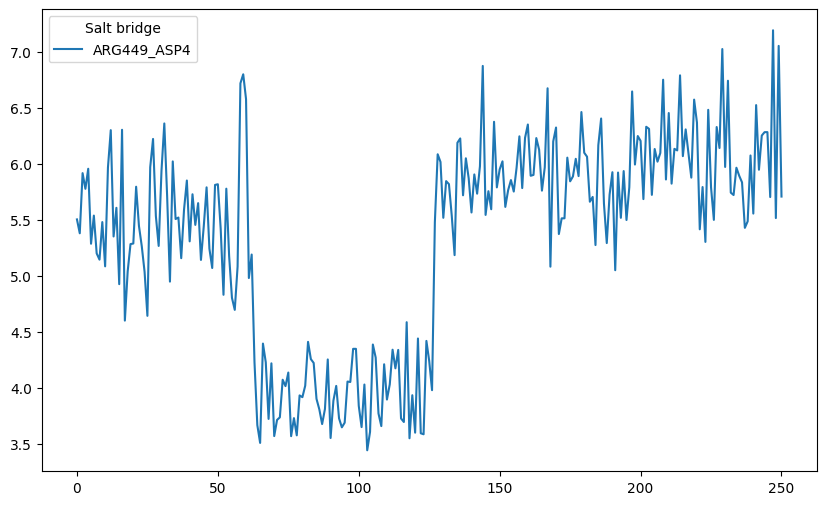

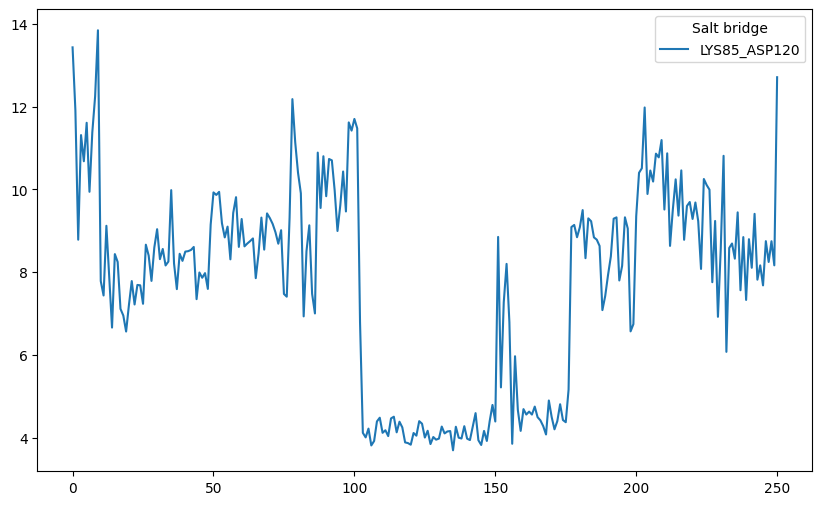

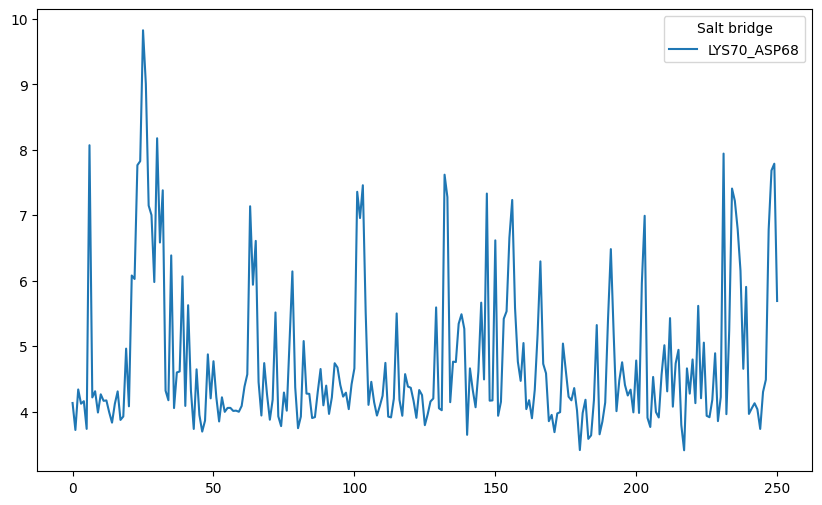

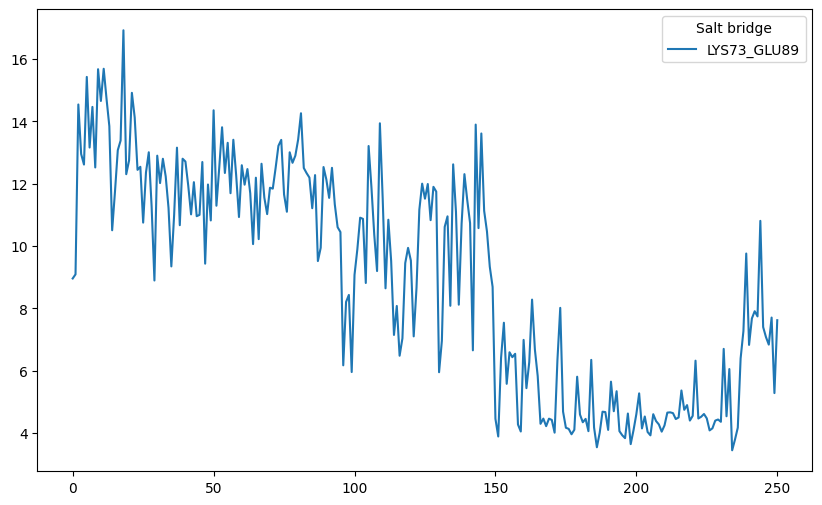

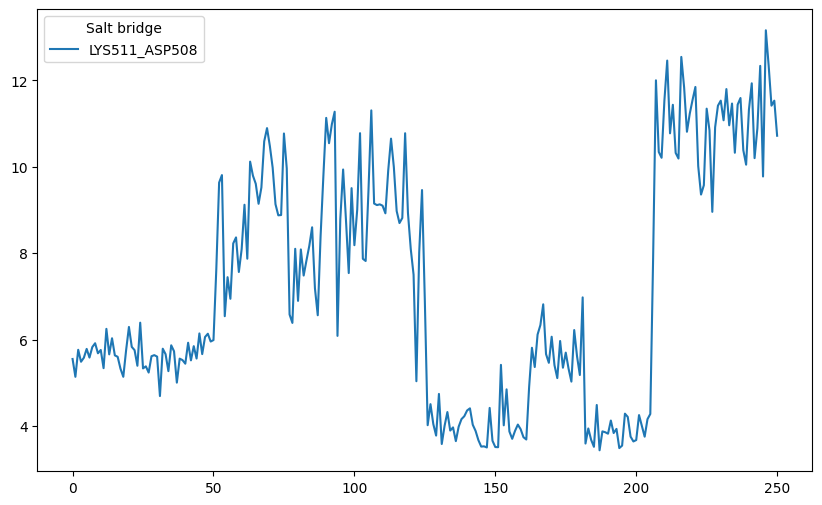

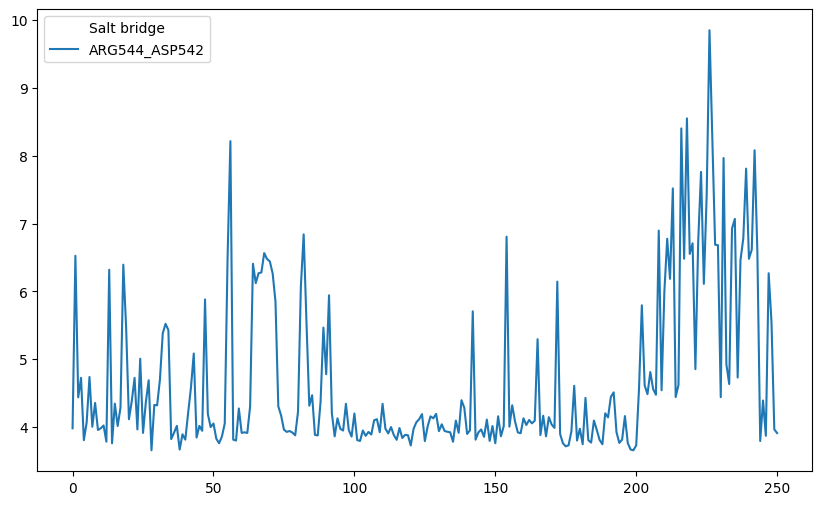

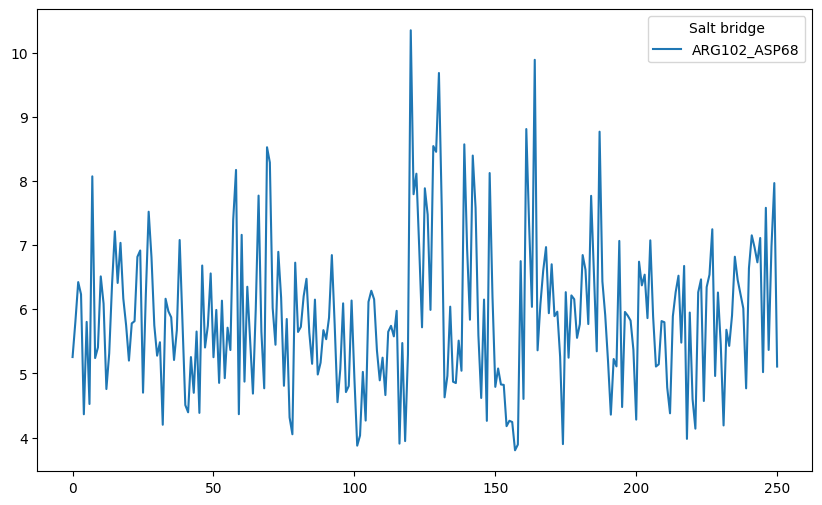

In [21]:
df2 = distance_df
sb_names = sb_names

df2.plot.line(y=[f'{sb_names[0]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[1]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[2]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[3]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[4]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[5]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[6]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[7]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[8]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[9]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[10]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[11]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[12]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[13]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[14]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[15]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[16]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[17]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[18]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[19]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[20]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[21]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[22]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[23]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[24]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[25]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[26]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[27]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[28]}'],  figsize=(10,6))